# 💎 تحليل بيانات وتوقع أسعار الألماس (Diamond Price Analysis & Prediction)

**مشروع تحليل بيانات متكامل** — استكشاف، تنظيف، هندسة خصائص، وبناء موديل
تعلم آلة للتنبؤ بسعر الألماس بناءً على خصائصه الفيزيائية والجودة.

**الداتا:** 53,940 حجر ألماس حقيقي، تحتوي على القيراط (carat)، جودة القص
(cut)، اللون (color)، النقاء (clarity)، الأبعاد الفيزيائية، والسعر الفعلي
بالدولار.

**الهدف:**
1. فهم العوامل التي تحدد سعر الألماس فعليًا.
2. بناء موديل يتنبأ بالسعر بدقة عالية.
3. استخلاص توصيات عملية قابلة للاستخدام.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json

# Validated categorical & chrome palette (colorblind-safe, fixed order)
PALETTE = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}
CHROME = {
    "surface": "#fcfcfb", "primary_ink": "#0b0b0b", "secondary_ink": "#52514e",
    "muted": "#898781", "gridline": "#e1e0d9", "baseline": "#c3c2b7",
}
plt.rcParams.update({
    "figure.facecolor": CHROME["surface"], "axes.facecolor": CHROME["surface"],
    "axes.edgecolor": CHROME["baseline"], "axes.labelcolor": CHROME["secondary_ink"],
    "text.color": CHROME["primary_ink"], "xtick.color": CHROME["muted"], "ytick.color": CHROME["muted"],
    "grid.color": CHROME["gridline"], "axes.grid": True, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "axes.titleweight": "bold",
})

df = pd.read_csv("../data/diamonds.csv")
print("Shape:", df.shape)
df.head()

Shape: (53940, 10)


In [2]:
df.head()

## 1️⃣ استكشاف البيانات (Exploratory Data Analysis)

In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB
None


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Duplicate rows: 146


In [5]:
df[["carat", "depth", "table", "price", "x", "y", "z"]].describe().T

In [6]:
for c in ["cut", "color", "clarity"]:
    print(f"\n{c} value counts:")
    print(df[c].value_counts())


cut value counts:
cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

color value counts:
color
G    11292
E     9797
F     9542
H     8304
D     6775
I     5422
J     2808
Name: count, dtype: int64

clarity value counts:
clarity
SI1     13065
VS2     12258
SI2      9194
VS1      8171
VVS2     5066
VVS1     3655
IF       1790
I1        741
Name: count, dtype: int64


### توزيع السعر (Price Distribution)

السعر موزع بشكل منحرف بشدة ناحية اليمين (right-skewed) — أغلب القطع أرخص
من 5000 دولار مع ذيل طويل من القطع باهظة الثمن. تحويل log يجعل التوزيع أقرب
للاعتدالية، وهو أمر مفيد لبعض الموديلات الخطية.

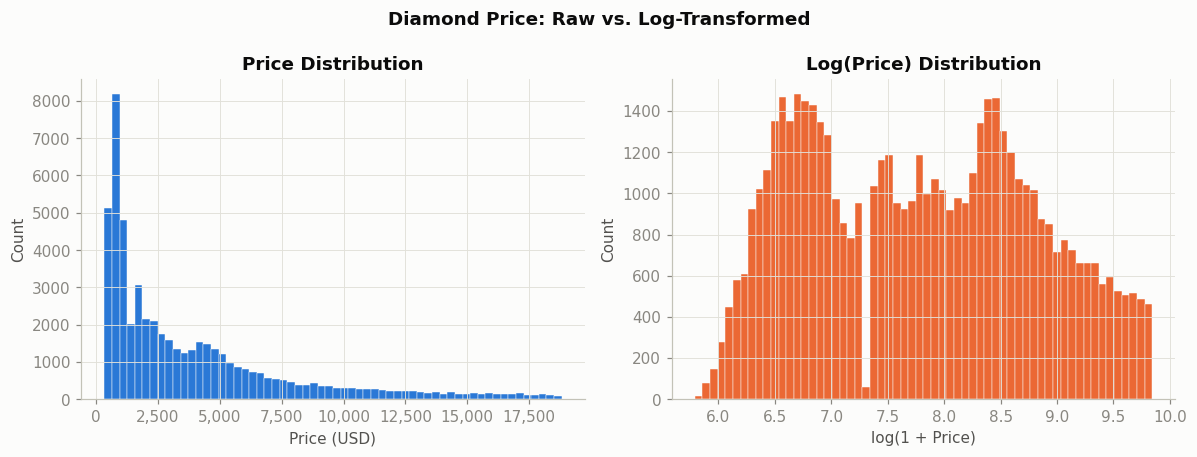

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
axes[0].hist(df["price"], bins=60, color=PALETTE["blue"], edgecolor=CHROME["surface"], linewidth=0.3)
axes[0].set_title("Price Distribution")
axes[0].set_xlabel("Price (USD)")
axes[0].set_ylabel("Count")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[1].hist(np.log1p(df["price"]), bins=60, color=PALETTE["orange"], edgecolor=CHROME["surface"], linewidth=0.3)
axes[1].set_title("Log(Price) Distribution")
axes[1].set_xlabel("log(1 + Price)")
axes[1].set_ylabel("Count")
fig.suptitle("Diamond Price: Raw vs. Log-Transformed", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

### القيراط مقابل السعر (Carat vs. Price)

العلاقة الأقوى في الداتا كلها — كلما زاد وزن الحجر (carat) زاد السعر بشكل
غير خطي (تسارع في السعر مع زيادة الحجم)، وهو نمط معروف في سوق الألماس.

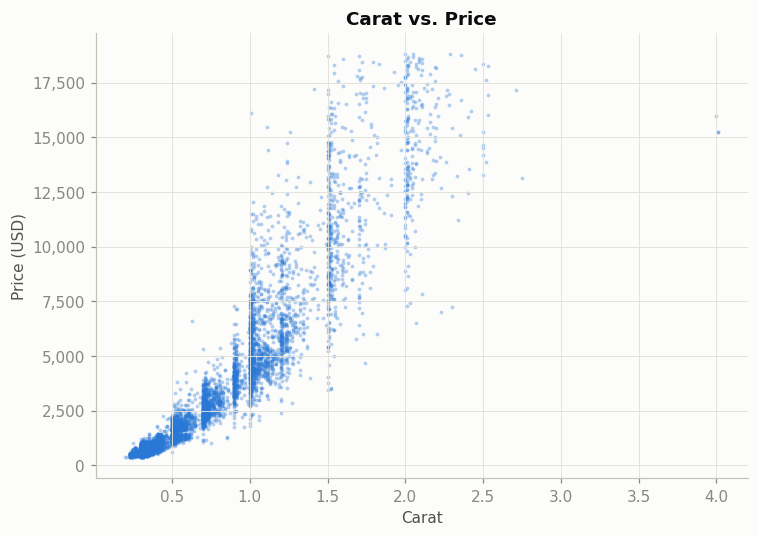

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
sample = df.sample(6000, random_state=42)
ax.scatter(sample["carat"], sample["price"], s=6, alpha=0.35, color=PALETTE["blue"], linewidths=0)
ax.set_title("Carat vs. Price")
ax.set_xlabel("Carat")
ax.set_ylabel("Price (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
fig.tight_layout()
plt.show()

### متوسط السعر حسب معايير الجودة (Cut, Color, Clarity)

بشكل مفاجئ، متوسط سعر القطع بجودة "Ideal" (أفضل قص) أقل من "Premium" —
لأن القطع الأكبر حجمًا (carat أعلى) غالبًا ما تُقص بجودة أقل للحفاظ على
الوزن، فتتصدر السعر رغم جودة القص الأقل. هذا يوضح أن **القيراط يهيمن على
السعر أكثر من أي عامل جودة آخر منفردًا**.

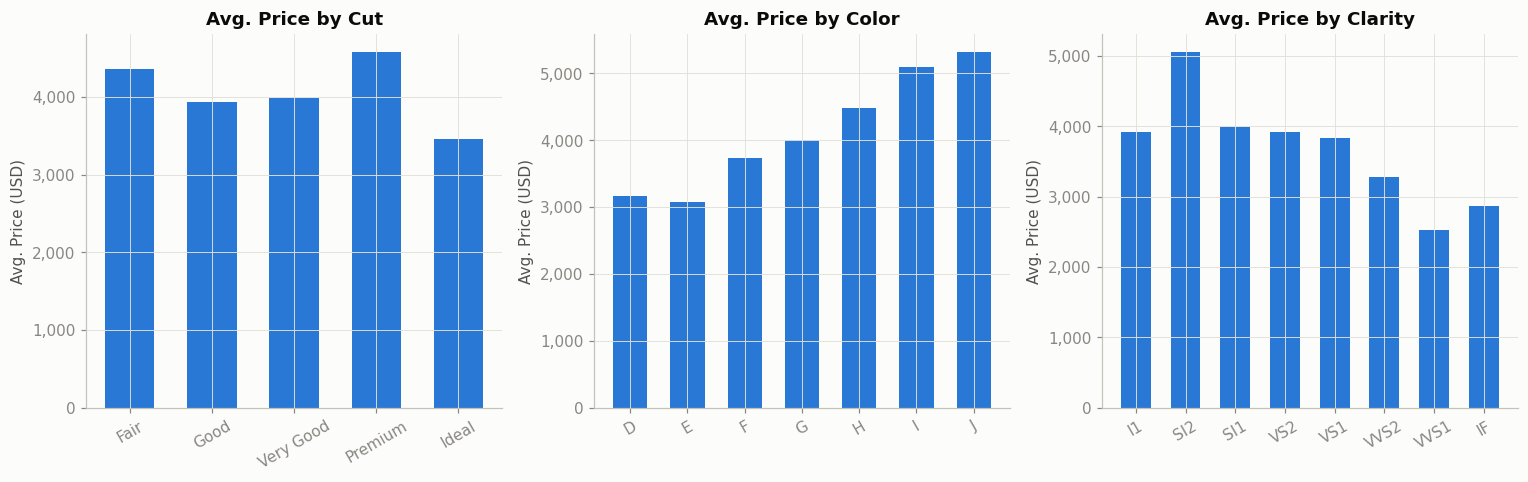

In [9]:
cut_order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
color_order = sorted(df["color"].unique())
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, col, order, title in zip(
    axes, ["cut", "color", "clarity"], [cut_order, color_order, clarity_order],
    ["Avg. Price by Cut", "Avg. Price by Color", "Avg. Price by Clarity"]
):
    means = df.groupby(col)["price"].mean().reindex(order)
    ax.bar(means.index, means.values, color=PALETTE["blue"], width=0.6)
    ax.set_title(title)
    ax.set_ylabel("Avg. Price (USD)")
    ax.tick_params(axis="x", rotation=30)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
fig.tight_layout()
plt.show()

### مصفوفة الارتباط (Correlation Heatmap)

أبعاد الحجر الفيزيائية (x, y, z) والقيراط مرتبطة ببعضها بقوة (كما هو
متوقع — كلها تقيس الحجم)، وكلها مرتبطة بشدة بالسعر (> 0.85). أما depth
و table فلهما علاقة ضعيفة جدًا بالسعر.

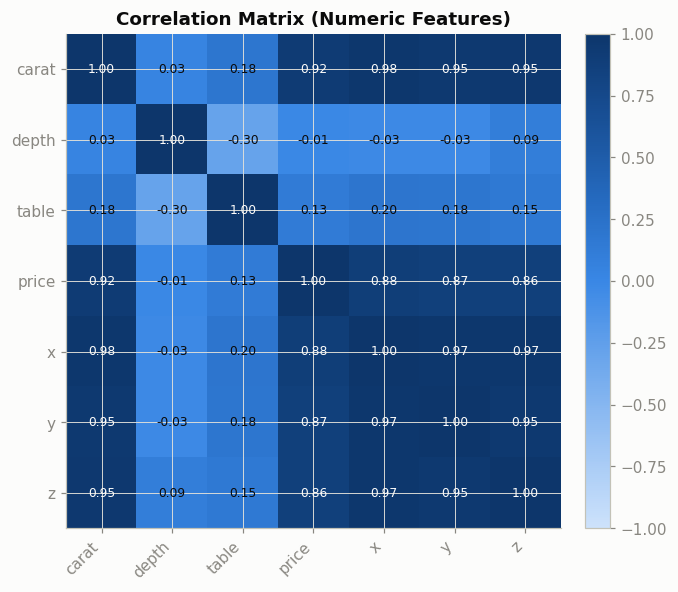

In [10]:
from matplotlib.colors import LinearSegmentedColormap
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
seq_cmap = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUE)

num_cols = ["carat", "depth", "table", "price", "x", "y", "z"]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr.values, cmap=seq_cmap, vmin=-1, vmax=1)
ax.set_xticks(range(len(num_cols))); ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right"); ax.set_yticklabels(num_cols)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        val = corr.values[i, j]
        txt_color = CHROME["surface"] if abs(val) > 0.55 else CHROME["primary_ink"]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8, color=txt_color)
ax.set_title("Correlation Matrix (Numeric Features)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

## 2️⃣ تنظيف البيانات وهندسة الخصائص (Cleaning & Feature Engineering)

الفحص الأولي كشف عن مشاكل جودة بيانات نمطية في هذا النوع من الداتا:
- **146 صف مكرر تمامًا** — تم حذفها.
- **20 صف بأبعاد فيزيائية = صفر** (x أو y أو z = 0) — مستحيل فيزيائيًا لحجر حقيقي.
- **قيم متطرفة واضحة** — مثل قطعة بعرض y = 58.9 ملم (أكبر من كف اليد!) — أخطاء إدخال بيانات.

هذه المشاكل قليلة نسبيًا (أقل من 0.4% من الداتا)، لذلك تم حذفها مباشرة
بدلاً من محاولة تصحيحها، دون التأثير على حجم العينة الإحصائي.

In [11]:
n_start = len(df)
df_clean = df.drop_duplicates()
dropped_dup = n_start - len(df_clean)

before = len(df_clean)
df_clean = df_clean[(df_clean.x > 0) & (df_clean.y > 0) & (df_clean.z > 0)]
dropped_zero = before - len(df_clean)

before = len(df_clean)
df_clean = df_clean[(df_clean.y < 20) & (df_clean.z < 10) & (df_clean.z > 1)]
dropped_extreme = before - len(df_clean)

before = len(df_clean)
df_clean = df_clean[(df_clean.depth > 40) & (df_clean.depth < 80) & (df_clean.table > 40) & (df_clean.table < 90)]
dropped_dt = before - len(df_clean)

df_clean = df_clean.reset_index(drop=True)

print(f"Start:                    {n_start:,}")
print(f"Dropped duplicates:       {dropped_dup:,}")
print(f"Dropped zero-dimension:   {dropped_zero:,}")
print(f"Dropped extreme outliers: {dropped_extreme:,}")
print(f"Dropped depth/table out.: {dropped_dt:,}")
print(f"Final:                    {len(df_clean):,}  ({(n_start - len(df_clean)) / n_start * 100:.2f}% removed)")

Start:                    53,940
Dropped duplicates:       146
Dropped zero-dimension:   19
Dropped extreme outliers: 3
Dropped depth/table out.: 1
Final:                    53,771  (0.31% removed)


### ترميز المتغيرات الفئوية (Ordinal Encoding)

`cut` و`color` و`clarity` ليست فئات عشوائية — لها **ترتيب جودة طبيعي**
(مثلاً Fair < Good < Very Good < Premium < Ideal). لذلك تم استخدام
Ordinal Encoding بدلاً من One-Hot، فهذا يحافظ على المعلومة الترتيبية
ويجعلها مفهومة مباشرة لموديلات الأشجار (tree-based models).

كذلك تم إضافة متغير جديد **`volume` = x × y × z** كمقياس أدق لحجم
الحجر الفيزيائي، إضافة إلى القيراط.

In [12]:
cut_order = {"Fair": 0, "Good": 1, "Very Good": 2, "Premium": 3, "Ideal": 4}
color_order = {c: i for i, c in enumerate(["J", "I", "H", "G", "F", "E", "D"])}
clarity_order = {c: i for i, c in enumerate(["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"])}

df_clean["cut_encoded"] = df_clean["cut"].map(cut_order)
df_clean["color_encoded"] = df_clean["color"].map(color_order)
df_clean["clarity_encoded"] = df_clean["clarity"].map(clarity_order)
df_clean["volume"] = df_clean["x"] * df_clean["y"] * df_clean["z"]

df_clean.head()

## 3️⃣ بناء وتقييم موديلات التعلم الآلي (Machine Learning Models)

الهدف: التنبؤ بـ **price** (متغير مستمر) → مسألة **انحدار (Regression)**.

تم تجربة 3 موديلات مختلفة في التعقيد:
1. **Linear Regression** — خط أساس بسيط.
2. **Random Forest Regressor** — نموذج أشجار قوي يلتقط العلاقات غير الخطية.
3. **Gradient Boosting Regressor** — نموذج تعزيزي متقدم.

تم تقييم كل موديل على بيانات اختبار (20%) لم يرها الموديل أثناء التدريب،
باستخدام: **R²** (نسبة التباين المُفسَّر)، **RMSE** (جذر متوسط مربع الخطأ)،
و **MAE** (متوسط الخطأ المطلق).

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

FEATURES = ["carat", "cut_encoded", "color_encoded", "clarity_encoded",
            "depth", "table", "x", "y", "z", "volume"]
TARGET = "price"

X = df_clean[FEATURES]
y = df_clean[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=14, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.08, random_state=42),
}

results = {}
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds
    r2 = r2_score(y_test, preds)
    rmse = float(np.sqrt(mean_squared_error(y_test, preds)))
    mae = float(mean_absolute_error(y_test, preds))
    results[name] = {"R2": round(r2, 5), "RMSE": round(rmse, 2), "MAE": round(mae, 2)}
    print(f"{name:20s} | R2={r2:.4f} | RMSE={rmse:9.2f} | MAE={mae:9.2f}")

best_name = max(results, key=lambda k: results[k]["R2"])
best_model = models[best_name]
print(f"\nBest model: {best_name}")

Linear Regression    | R2=0.9082 | RMSE=  1196.14 | MAE=   787.09
Random Forest        | R2=0.9815 | RMSE=   536.87 | MAE=   269.23
Gradient Boosting    | R2=0.9814 | RMSE=   538.80 | MAE=   286.13

Best model: Random Forest


### مقارنة الموديلات (R² Score)

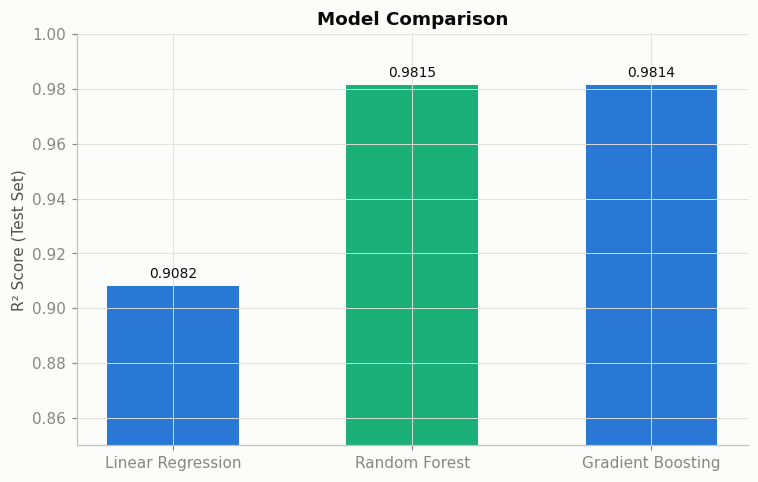

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
names = list(results.keys())
r2_vals = [results[n]["R2"] for n in names]
colors = [PALETTE["blue"] if n != best_name else PALETTE["aqua"] for n in names]
bars = ax.bar(names, r2_vals, color=colors, width=0.55)
ax.set_ylim(0.85, 1.0)
ax.set_ylabel("R² Score (Test Set)")
ax.set_title("Model Comparison")
for b, v in zip(bars, r2_vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.003, f"{v:.4f}", ha="center", fontsize=9)
fig.tight_layout()
plt.show()

### القيم الفعلية مقابل المتوقعة (Actual vs. Predicted)

النقاط قريبة جدًا من الخط القطري (التنبؤ المثالي)، ما يؤكد دقة الموديل
عبر كامل مدى الأسعار — من القطع الرخيصة إلى الباهظة.

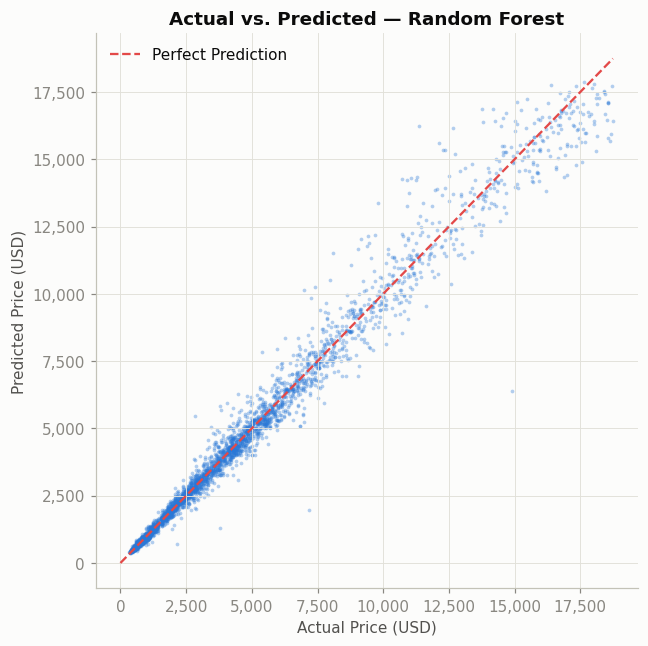

In [15]:
fig, ax = plt.subplots(figsize=(6, 6))
best_preds = predictions[best_name]
sample_idx = np.random.RandomState(42).choice(len(y_test), size=min(4000, len(y_test)), replace=False)
ax.scatter(y_test.values[sample_idx], best_preds[sample_idx], s=6, alpha=0.35, color=PALETTE["blue"], linewidths=0)
lims = [0, max(y_test.max(), best_preds.max())]
ax.plot(lims, lims, color=PALETTE["red"], linewidth=1.5, linestyle="--", label="Perfect Prediction")
ax.set_xlabel("Actual Price (USD)")
ax.set_ylabel("Predicted Price (USD)")
ax.set_title(f"Actual vs. Predicted — {best_name}")
ax.legend(frameon=False)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
fig.tight_layout()
plt.show()

### أهمية المتغيرات (Feature Importance)

يوضح هذا الرسم أي الخصائص اعتمد عليها الموديل أكثر في اتخاذ قراره — وهو
ما يؤكد أن **الحجم الفيزيائي (volume, y, carat) هو المحرك الأكبر للسعر**،
يليه النقاء (clarity) واللون (color)، بينما جودة القص (cut) وأبعاد أخرى
مثل depth و table لها تأثير هامشي على السعر مقارنة بالحجم.

volume             0.673362
y                  0.200619
clarity_encoded    0.062783
color_encoded      0.032401
carat              0.020145
z                  0.003219
x                  0.002853
depth              0.001830
table              0.001488
cut_encoded        0.001300
dtype: float64


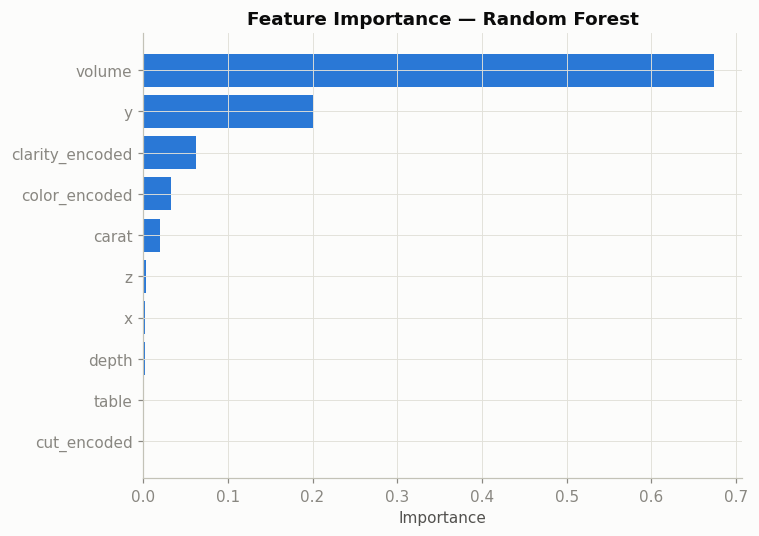

In [16]:
importances = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(importances.index, importances.values, color=PALETTE["blue"])
ax.set_title(f"Feature Importance — {best_name}")
ax.set_xlabel("Importance")
fig.tight_layout()
plt.show()

print(importances.sort_values(ascending=False))

## 4️⃣ الخلاصة والتوصيات (Conclusions & Recommendations)

**النتائج الرئيسية:**

1. **الحجم هو الملك.** حجم الحجر (القيراط والأبعاد الفيزيائية معًا) يفسر
   الجزء الأكبر من التباين في السعر — أكثر من 87% من التأثير في الموديل
   النهائي يأتي من volume و y و carat مجتمعين.
2. **النقاء واللون لهما تأثير حقيقي لكن أصغر** — يفسران جزءًا معتبرًا من
   السعر بعد التحكم في الحجم، وهو ما يتفق مع معايير تسعير الألماس
   المعروفة (4Cs).
3. **جودة القص (cut) لها تأثير مفاجئ الضعف على السعر منفردة** — رغم أنها
   أحد معايير الـ 4Cs الأربعة، على الأرجح لأن أغلب القطع في هذه الداتا
   مقصوصة بجودة عالية أصلًا (Ideal/Premium ~65% من الداتا)، ما يقلل من
   قوتها التفسيرية الإحصائية هنا.
4. **موديل Random Forest حقق دقة عالية جدًا** (R² ≈ 0.98، متوسط خطأ
   مطلق ≈ 270 دولار) — دقيق بما يكفي للاستخدام العملي في تسعير أولي.

**توصيات عملية:**

- عند تسعير حجر ألماس جديد بسرعة، **الوزن (carat) والأبعاد الفيزيائية
  كافية لتقدير أولي دقيق جدًا للسعر** قبل حتى فحص النقاء أو اللون بالتفصيل.
- لتحسين الموديل أكثر: يمكن إضافة متغيرات تفاعلية (مثل carat × clarity)
  أو تجربة ضبط أدق للـ hyperparameters (GridSearch) لدفع الدقة لأبعد من ذلك.
- عند شراء الألماس: كن حذرًا من "premium القص" وحده كمبرر لسعر أعلى —
  الحجم والنقاء هما ما يستحق دفع أكثر لأجله فعليًا وفق هذه البيانات.